In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-Learn
from cuml.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from scipy.stats import randint, uniform, loguniform

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')
from sklearn.exceptions import DataConversionWarning

# Suppress the annoying LightGBM feature name warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings(action='ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# Helper function for Confusion Matrices
def plot_cm(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("🚀 CELL 1: PREPARING DATA\n" + "="*50)

# 1. Load Data
train_data = np.load("/kaggle/input/datasets/anasibrahem101/last-split-by-me/train_data.npz")
X_train, y_train = train_data['X'], train_data['y']
train2_data = np.load("/kaggle/input/datasets/anasibrahem101/last-split-by-me/test_data.npz")
X_train2, y_train2 = train2_data['X'], train2_data['y']
X_train = np.vstack((X_train, X_train2))
y_train = np.concatenate((y_train, y_train2))

test_data = np.load("/kaggle/input/datasets/anasibrahem101/last-split-by-me/val_data.npz")
X_test, y_test = test_data['X'], test_data['y']


# 2. Merge Train and Val for Cross-Validation
# X_cv = np.vstack((X_train, X_val))
# y_cv = np.concatenate((y_train, y_val))
X_cv = X_train
y_cv = y_train
# 3. Label Mapping
machine_map = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
binary_map  = {0: 0, 1: 1, 2: 0, 3: 1, 4: 0, 5: 1}
target_names = ["M1_Norm", "M1_Abn", "M2_Norm", "M2_Abn", "M3_Norm", "M3_Abn"]

y_cv_mach = np.array([machine_map[y] for y in y_cv])
y_cv_bin  = np.array([binary_map[y] for y in y_cv])
y_test_mach = np.array([machine_map[y] for y in y_test])

print(f"✅ Data Ready! CV Shape: {X_cv.shape}, Test Shape: {X_test.shape}")

2026-05-01 01:01:36.299861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777597296.476715      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777597296.528697      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777597296.945240      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777597296.945275      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777597296.945277      57 computation_placer.cc:177] computation placer alr

🚀 CELL 1: PREPARING DATA
✅ Data Ready! CV Shape: (42384, 256), Test Shape: (13852, 256)


🚀 CELL 2: STAGE 1 - SVM ROUTER
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[2026-05-01 01:02:01.942] [CUML] [warning] Sample weights are currently ignored for multi class classification
[CV] END C=3.14891164795686, gamma=0.711447600934342, kernel=rbf; total time= 1.3min
[CV] END C=3.14891164795686, gamma=0.711447600934342, kernel=rbf; total time= 1.2min
[CV] END C=3.14891164795686, gamma=0.711447600934342, kernel=rbf; total time= 1.2min
[CV] END C=84.71801418819973, gamma=0.06251373574521749, kernel=rbf; total time=  28.1s
[CV] END C=84.71801418819973, gamma=0.06251373574521749, kernel=rbf; total time=  28.4s
[CV] END C=84.71801418819973, gamma=0.06251373574521749, kernel=rbf; total time=  23.5s
[CV] END C=0.42079886696066343, gamma=0.0029375384576328283, kernel=rbf; total time=   3.3s
[CV] END C=0.42079886696066343, gamma=0.0029375384576328283, kernel=rbf; total time=   3.2s
[CV] END C=0.42079886696066343, gamma=0.0029375384576328283, kernel=rbf; total time=   3.2s
[C

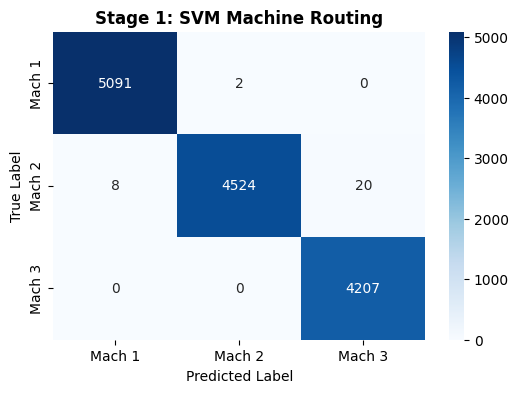

In [2]:
print("🚀 CELL 2: STAGE 1 - SVM ROUTER\n" + "="*50)

X_cv_svm = X_cv.astype(np.float64)
X_test_svm = X_test.astype(np.float64)

param_dist_svm = {
    'C': loguniform(0.1, 1000),
    'gamma': loguniform(0.001, 1.0),
    'kernel': ['rbf']
}

random_router = RandomizedSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42, verbose=0),  # verbose=0
    param_distributions=param_dist_svm,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,          # ← KEY FIX: cuML SVC must run sequentially, not in parallel workers
    verbose=2,         # outer verbosity is fine, it's the inner SVC verbose that caused issues
    random_state=42
)

random_router.fit(X_cv_svm, y_cv_mach)
best_router = random_router.best_estimator_
print(f"✅ Best Router Params: {random_router.best_params_}")

t0 = time.perf_counter()
pred_mach_test = best_router.predict(X_test_svm)
t1 = time.perf_counter()

svm_router_time_ms = ((t1 - t0) / len(X_test_svm)) * 1000

print(f"\n⏱️ SVM Router Avg Inference Time: {svm_router_time_ms:.4f} ms / sample")
print("\n--- Stage 1 Metrics (Machine Classification) ---")
print(classification_report(y_test_mach, pred_mach_test, target_names=["Mach 1", "Mach 2", "Mach 3"]))
plot_cm(y_test_mach, pred_mach_test, "Stage 1: SVM Machine Routing", ["Mach 1", "Mach 2", "Mach 3"])

router_probs_test = best_router.predict_proba(X_test_svm)

🚀 CELL: STAGE 2 - TUNED ISOLATION FOREST

🔍 Tuning Isolation Forest for Machine 1...
   ✅ Best Params: {'contamination': np.float64(0.17648852816008437), 'max_features': np.float64(0.6061695553391381), 'max_samples': 1.0, 'n_estimators': 400}

🔍 Tuning Isolation Forest for Machine 2...
   ✅ Best Params: {'contamination': np.float64(0.10121399684340719), 'max_features': np.float64(0.8925879806965068), 'max_samples': 0.75, 'n_estimators': 400}

🔍 Tuning Isolation Forest for Machine 3...
   ✅ Best Params: {'contamination': np.float64(0.09638900372842316), 'max_features': np.float64(0.645614570099021), 'max_samples': 0.75, 'n_estimators': 300}

⏱️ SVM + Tuned Isolation Forest Avg Inference Time: 0.2769 ms / sample

--- Final Two-Stage Metrics (SVM + Tuned Isolation Forest) ---
              precision    recall  f1-score   support

     M1_Norm       0.97      0.16      0.28      4350
      M1_Abn       0.16      0.97      0.28       743
     M2_Norm       0.68      0.24      0.35      3653

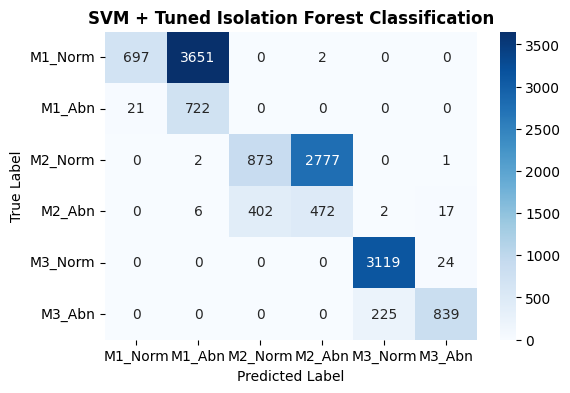

In [3]:
import time
import numpy as np
from scipy.stats import uniform, randint
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, make_scorer, f1_score

print("🚀 CELL: STAGE 2 - TUNED ISOLATION FOREST\n" + "="*50)

# 1. Custom Scorer to bridge the label mismatch
def mapped_iforest_f1(y_true, y_pred_raw):
    # IsolationForest outputs: 1 (Inlier/Normal), -1 (Outlier/Abnormal)
    # Our labels are:          0 (Normal),         1 (Abnormal)
    y_pred_mapped = np.where(y_pred_raw == 1, 0, 1)
    
    # Use macro F1 to ensure both classes are weighted equally
    return f1_score(y_true, y_pred_mapped, average='macro')

# Wrap the function into a Scikit-Learn scorer
iforest_scorer = make_scorer(mapped_iforest_f1)

# 2. Hyperparameter Space
param_dist_iforest = {
    'n_estimators': [100, 200, 300, 400],
    'max_samples': ['auto', 0.5, 0.75, 1.0],        # Subsampling ratio to build trees
    'contamination': uniform(0.01, 0.2),            # Guessing anomaly fraction between 1% and 21%
    'max_features': uniform(0.5, 0.5)               # Training trees on 50% to 100% of the 256 features
}

machine_tuned_iforests = {}

# 3. Training Loop
for mach_id in range(3):
    print(f"\n🔍 Tuning Isolation Forest for Machine {mach_id + 1}...")
    
    # Isolate data for the specific machine
    mask = (y_cv_mach == mach_id)
    X_mach, y_mach_bin = X_cv[mask], y_cv_bin[mask]
    
    iforest_base = IsolationForest(random_state=42, n_jobs=-1)
    
    # Note: Even though IForest is unsupervised, we pass 'y_mach_bin' to fit() 
    # ONLY so the RandomizedSearchCV can use it for our custom scoring function.
    random_iforest = RandomizedSearchCV(
        estimator=iforest_base,
        param_distributions=param_dist_iforest,
        n_iter=10, 
        cv=3, 
        scoring=iforest_scorer, 
        n_jobs=-1, 
        verbose=0, 
        random_state=42
    )
    
    random_iforest.fit(X_mach, y_mach_bin)
    machine_tuned_iforests[mach_id] = random_iforest.best_estimator_
    print(f"   ✅ Best Params: {random_iforest.best_params_}")

# ==========================================
# ── INFERENCE & TIMING ──
# ==========================================
t0 = time.perf_counter()
pred_mach_all = best_router.predict(X_test) # Routed by Stage 1
pred_state_iforest = np.zeros_like(pred_mach_all)

for mach_id in range(3):
    idx = np.where(pred_mach_all == mach_id)[0]
    if len(idx) > 0:
        raw_preds = machine_tuned_iforests[mach_id].predict(X_test[idx])
        # Map: 1 -> 0 (Normal), -1 -> 1 (Abnormal)
        pred_state_iforest[idx] = np.where(raw_preds == 1, 0, 1)

t1 = time.perf_counter()
iforest_final_preds = (pred_mach_all * 2) + pred_state_iforest
iforest_time_ms = ((t1 - t0) / len(X_test)) * 1000

print(f"\n⏱️ SVM + Tuned Isolation Forest Avg Inference Time: {iforest_time_ms:.4f} ms / sample")
print("\n--- Final Two-Stage Metrics (SVM + Tuned Isolation Forest) ---")
print(classification_report(y_test, iforest_final_preds, target_names=target_names))
plot_cm(y_test, iforest_final_preds, "SVM + Tuned Isolation Forest Classification", target_names)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 10.2 MB/s eta 0:00:0000:01
🚀 CELL: STAGE 2 - TUNED HBOS

🔍 Tuning HBOS for Machine 1...
   ✅ Best F1: 0.6548

🔍 Tuning HBOS for Machine 2...
   ✅ Best F1: 0.7369

🔍 Tuning HBOS for Machine 3...
   ✅ Best F1: 0.8593

⏱️ SVM + HBOS Avg Inference Time: 0.0299 ms / sample

--- Final Two-Stage Metrics (SVM + HBOS) ---
              precision    recall  f1-score   support

     M1_Norm       0.90      0.87      0.89      4350
      M1_Abn       0.36      0.44      0.40       743
     M2_Norm       0.83      0.56      0.67      3653
      M2_Abn       0.22      0.49      0.30       899
     M3_Norm       0.91      1.00      0.95      3143
      M3_Abn       0.99      0.71      0.83      1064

    accuracy                           0.76     13852
   macro avg       0.70      0.68      0.67     13852
weighted avg       0.82      0.76      0.77     13852



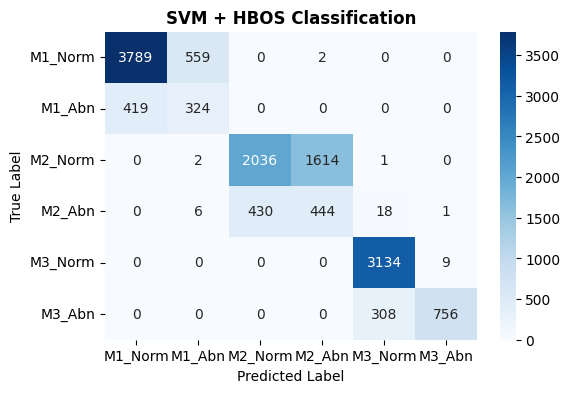

In [4]:
!pip install pyod
from pyod.models.hbos import HBOS
from sklearn.metrics import f1_score

print("🚀 CELL: STAGE 2 - TUNED HBOS\n" + "="*50)

param_dist_hbos = {
    'n_bins': [5, 10, 20, 50],
    'contamination': uniform(0.01, 0.2)
}

machine_tuned_hbos = {}

for mach_id in range(3):
    print(f"\n🔍 Tuning HBOS for Machine {mach_id + 1}...")
    
    mask = (y_cv_mach == mach_id)
    X_mach, y_mach_bin = X_cv[mask], y_cv_bin[mask]

    best_f1 = -1

    for bins in param_dist_hbos['n_bins']:
        for cont in [0.01, 0.05, 0.1]:
            
            hbos = HBOS(n_bins=bins, contamination=cont)
            hbos.fit(X_mach)

            preds = hbos.predict(X_mach)
            f1 = f1_score(y_mach_bin, preds, average='macro')

            if f1 > best_f1:
                best_f1 = f1
                machine_tuned_hbos[mach_id] = hbos

    print(f"   ✅ Best F1: {best_f1:.4f}")

# ==========================================
# ── INFERENCE & TIMING ──
# ==========================================
t0 = time.perf_counter()
pred_mach_all = best_router.predict(X_test)
pred_state_hbos = np.zeros_like(pred_mach_all)

for mach_id in range(3):
    idx = np.where(pred_mach_all == mach_id)[0]
    if len(idx) > 0:
        preds = machine_tuned_hbos[mach_id].predict(X_test[idx])
        pred_state_hbos[idx] = preds  # already 0/1

t1 = time.perf_counter()
hbos_final_preds = (pred_mach_all * 2) + pred_state_hbos
hbos_time_ms = ((t1 - t0) / len(X_test)) * 1000

print(f"\n⏱️ SVM + HBOS Avg Inference Time: {hbos_time_ms:.4f} ms / sample")
print("\n--- Final Two-Stage Metrics (SVM + HBOS) ---")
print(classification_report(y_test, hbos_final_preds, target_names=target_names))
plot_cm(y_test, hbos_final_preds, "SVM + HBOS Classification", target_names)

🚀 CELL 3: STAGE 2 - XGBOOST PER MACHINE

🔍 Tuning XGBoost for Machine 1...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:20:17] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:20:17] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

   ✅ Best Params: {'colsample_bytree': np.float64(0.9795542149013333), 'learning_rate': np.float64(0.26690431824362526), 'max_depth': 4, 'n_estimators': 364, 'subsample': np.float64(0.6063865008880857)}

🔍 Tuning XGBoost for Machine 2...
   ✅ Best Params: {'colsample_bytree': np.float64(0.9795542149013333), 'learning_rate': np.float64(0.26690431824362526), 'max_depth': 4, 'n_estimators': 364, 'subsample': np.float64(0.6063865008880857)}

🔍 Tuning XGBoost for Machine 3...
   ✅ Best Params: {'colsample_bytree': np.float64(0.9795542149013333), 'learning_rate': np.float64(0.26690431824362526), 'max_depth': 4, 'n_estimators': 364, 'subsample': np.float64(0.6063865008880857)}

⏱️ Full XGBoost Pipeline Avg Inference Time: 0.0160 ms / sample

--- Final Hybrid Two-Stage Metrics (SVM + 3x XGBoost) ---
              precision    recall  f1-score   support

     M1_Norm       0.97      0.92      0.94      4350
      M1_Abn       0.62      0.82      0.71       743
     M2_Norm       0.96      0.88 

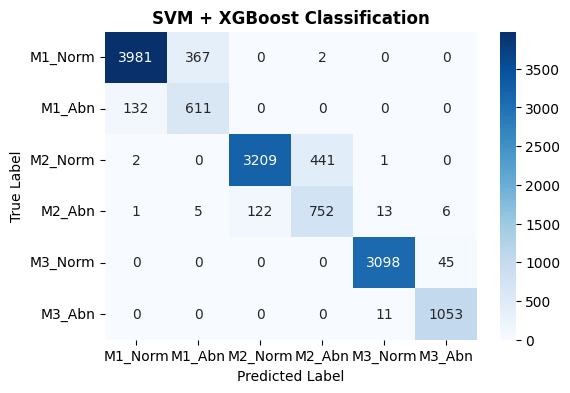

In [5]:
print("🚀 CELL 3: STAGE 2 - XGBOOST PER MACHINE\n" + "="*50)

machine_xgbs = {}

# Logical Hyperparameters for XGBoost (Deep Trees)
param_dist_xgb = {
    'max_depth': randint(3, 10),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(100, 500),
    'subsample': uniform(0.6, 0.4),        # 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4)  # 0.6 to 1.0
}

for mach_id in range(3):
    print(f"\n🔍 Tuning XGBoost for Machine {mach_id + 1}...")
    mask = (y_cv_mach == mach_id)
    X_cv_mach, y_cv_bin_mach = X_cv[mask], y_cv_bin[mask]
    sample_weights_bin = compute_sample_weight(class_weight='balanced', y=y_cv_bin_mach)
    
    xgb_base = XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', device='cuda',          # explicit GPU
        feature_names=None,                         # suppress feature name warning
        random_state=42
    )

    random_xgb = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist_xgb,
        n_iter=10, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0, random_state=42
    )

    random_xgb.fit(X_cv_mach, y_cv_bin_mach, sample_weight=sample_weights_bin)
    machine_xgbs[mach_id] = random_xgb.best_estimator_
    print(f"   ✅ Best Params: {random_xgb.best_params_}")

# ── INFERENCE & TIMING ──
t0 = time.perf_counter()
pred_mach_all = best_router.predict(X_test)
pred_state_xgb = np.zeros_like(pred_mach_all)
for mach_id in range(3):
    idx = np.where(pred_mach_all == mach_id)[0]
    if len(idx) > 0:
        pred_state_xgb[idx] = machine_xgbs[mach_id].predict(X_test[idx])
t1 = time.perf_counter()

xgb_pipeline_time_ms = ((t1 - t0) / len(X_test)) * 1000
xgb_final_preds = (pred_mach_all * 2) + pred_state_xgb

# Generate Full Soft Probability Matrix for Ensemble
xgb_final_probs = np.zeros((len(X_test), 6))
for mach_id in range(3):
    stg2_probs = machine_xgbs[mach_id].predict_proba(X_test) # Predict all to get (N, 2)
    xgb_final_probs[:, mach_id*2] = router_probs_test[:, mach_id] * stg2_probs[:, 0]
    xgb_final_probs[:, mach_id*2 + 1] = router_probs_test[:, mach_id] * stg2_probs[:, 1]

print(f"\n⏱️ Full XGBoost Pipeline Avg Inference Time: {xgb_pipeline_time_ms:.4f} ms / sample")
print("\n--- Final Hybrid Two-Stage Metrics (SVM + 3x XGBoost) ---")
print(classification_report(y_test, xgb_final_preds, target_names=target_names))
plot_cm(y_test, xgb_final_preds, "SVM + XGBoost Classification", target_names)

🚀 CELL 5a: STAGE 2 - SHALLOW NEURAL NETWORK (TF)

🔍 Training Shallow NN for Machine 1...


I0000 00:00:1777598569.131697      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13239 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777598569.136816      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777598572.086560     866 service.cc:152] XLA service 0x7d08e800a6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777598572.086610     866 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777598572.086615     866 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777598572.483098     866 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777598574.574256     866 device_compiler.h:188] Compiled clust


🔍 Training Shallow NN for Machine 2...

🔍 Training Shallow NN for Machine 3...

⏱️ SVM + Per-Machine NN Avg Inference Time: 0.2273 ms / sample

--- Final Two-Stage Metrics (SVM + NN) ---
              precision    recall  f1-score   support

     M1_Norm       0.99      0.98      0.98      4350
      M1_Abn       0.87      0.94      0.91       743
     M2_Norm       0.92      0.73      0.81      3653
      M2_Abn       0.39      0.72      0.51       899
     M3_Norm       0.99      1.00      0.99      3143
      M3_Abn       0.97      0.97      0.97      1064

    accuracy                           0.90     13852
   macro avg       0.86      0.89      0.86     13852
weighted avg       0.92      0.90      0.90     13852



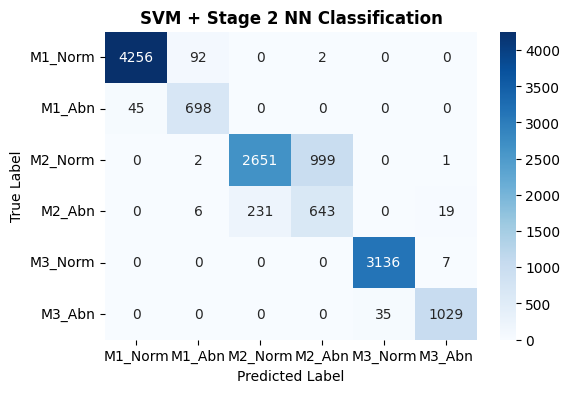

In [6]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

print("🚀 CELL 5a: STAGE 2 - SHALLOW NEURAL NETWORK (TF)\n" + "="*50)

machine_nns = {}

def build_shallow_stage2_nn(in_dim):
    inputs = layers.Input(shape=(in_dim,))
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-3))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(2, activation='softmax')(x) 
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

for mach_id in range(3):
    print(f"\n🔍 Training Shallow NN for Machine {mach_id + 1}...")
    mask = (y_cv_mach == mach_id)
    X_mach, y_mach_bin = X_cv[mask], y_cv_bin[mask]
    
    scaler_nn = StandardScaler()
    X_mach_scaled = scaler_nn.fit_transform(X_mach)
    
    cw_bin = compute_class_weight('balanced', classes=np.unique(y_mach_bin), y=y_mach_bin)
    
    nn_model = build_shallow_stage2_nn(X_mach_scaled.shape[1])
    early_stop = callbacks.EarlyStopping(monitor='loss', patience=4, restore_best_weights=True)
    
    nn_model.fit(
        X_mach_scaled, y_mach_bin, 
        epochs=30, batch_size=128, 
        class_weight=dict(enumerate(cw_bin)), 
        callbacks=[early_stop], 
        verbose=0
    )
    machine_nns[mach_id] = (scaler_nn, nn_model)

# --- INFERENCE & EVALUATION ---
t0 = time.perf_counter()
pred_mach_all = best_router.predict(X_test) # From Stage 1
pred_state_nn = np.zeros_like(pred_mach_all)

for mach_id in range(3):
    idx = np.where(pred_mach_all == mach_id)[0]
    if len(idx) > 0:
        scaler_nn, nn_model = machine_nns[mach_id]
        X_scaled = scaler_nn.transform(X_test[idx])
        probs = nn_model.predict(X_scaled, verbose=0)
        pred_state_nn[idx] = np.argmax(probs, axis=1)

t1 = time.perf_counter()
nn_final_preds = (pred_mach_all * 2) + pred_state_nn
nn_time_ms = ((t1 - t0) / len(X_test)) * 1000

print(f"\n⏱️ SVM + Per-Machine NN Avg Inference Time: {nn_time_ms:.4f} ms / sample")
print("\n--- Final Two-Stage Metrics (SVM + NN) ---")
print(classification_report(y_test, nn_final_preds, target_names=target_names))
plot_cm(y_test, nn_final_preds, "SVM + Stage 2 NN Classification", target_names)

🚀 CELL 5b: STAGE 2 - DEEP RESIDUAL MLP NN (TF)

🔍 Training Deep Residual MLP for Machine 1...
   ✅ Machine 1 done — 482,658 params

🔍 Training Deep Residual MLP for Machine 2...
   ✅ Machine 2 done — 482,658 params

🔍 Training Deep Residual MLP for Machine 3...
   ✅ Machine 3 done — 482,658 params

⏱️ SVM + Deep Residual MLP Avg Inference Time: 0.3335 ms / sample

--- Final Two-Stage Metrics (SVM + Deep Residual MLP) ---
              precision    recall  f1-score   support

     M1_Norm       0.99      0.95      0.97      4350
      M1_Abn       0.77      0.93      0.84       743
     M2_Norm       0.99      0.51      0.67      3653
      M2_Abn       0.32      0.96      0.48       899
     M3_Norm       0.99      1.00      1.00      3143
      M3_Abn       0.98      0.98      0.98      1064

    accuracy                           0.85     13852
   macro avg       0.84      0.89      0.82     13852
weighted avg       0.93      0.85      0.86     13852



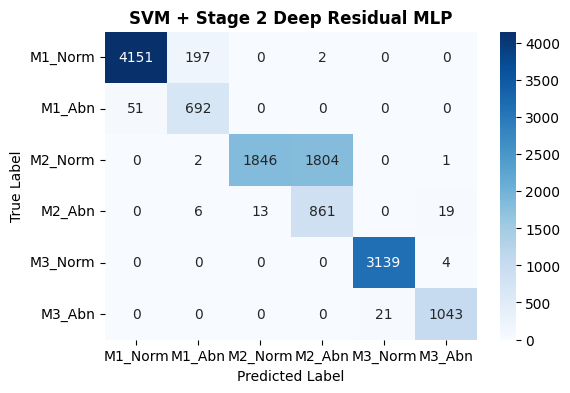

In [7]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

print("🚀 CELL 5b: STAGE 2 - DEEP RESIDUAL MLP NN (TF)\n" + "="*50)

machine_deep_nns = {}

def build_deep_stage2_nn(in_dim):
    """
    Deeper Stage-2 NN with residual skip connections.
    Architecture: 5 dense blocks (512→256→128→64→32) with skip projections.
    """
    inputs = layers.Input(shape=(in_dim,))

    # --- Block 1: 512 ---
    x = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    # --- Block 2: 256 + skip from block 1 (projected) ---
    skip = layers.Dense(256)(x)                           # project skip to 256
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Add()([x, skip])

    # --- Block 3: 128 + skip ---
    skip = layers.Dense(128)(x)
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Add()([x, skip])

    # --- Block 4: 64 + skip ---
    skip = layers.Dense(64)(x)
    x = layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Add()([x, skip])

    # --- Block 5: 32 ---
    x = layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(2, activation='softmax')(x)
    model = models.Model(inputs, outputs, name="DeepResidualMLP_Stage2")
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

for mach_id in range(3):
    print(f"\n🔍 Training Deep Residual MLP for Machine {mach_id + 1}...")
    mask = (y_cv_mach == mach_id)
    X_mach, y_mach_bin = X_cv[mask], y_cv_bin[mask]

    scaler_dnn = StandardScaler()
    X_mach_scaled = scaler_dnn.fit_transform(X_mach)

    cw_bin = compute_class_weight('balanced', classes=np.unique(y_mach_bin), y=y_mach_bin)

    deep_nn = build_deep_stage2_nn(X_mach_scaled.shape[1])

    cb_list = [
        callbacks.EarlyStopping(monitor='loss', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

    deep_nn.fit(
        X_mach_scaled, y_mach_bin,
        epochs=60, batch_size=64,
        class_weight=dict(enumerate(cw_bin)),
        callbacks=cb_list,
        verbose=0
    )
    machine_deep_nns[mach_id] = (scaler_dnn, deep_nn)
    print(f"   ✅ Machine {mach_id + 1} done — {deep_nn.count_params():,} params")

# --- INFERENCE & EVALUATION ---
t0 = time.perf_counter()
pred_mach_all = best_router.predict(X_test)
pred_state_deep_nn = np.zeros_like(pred_mach_all)

deep_nn_final_probs = np.zeros((len(X_test), 6))
for mach_id in range(3):
    idx = np.where(pred_mach_all == mach_id)[0]
    if len(idx) > 0:
        scaler_dnn, deep_nn = machine_deep_nns[mach_id]
        X_scaled = scaler_dnn.transform(X_test[idx])
        probs = deep_nn.predict(X_scaled, verbose=0)
        pred_state_deep_nn[idx] = np.argmax(probs, axis=1)
        # Build full 6-class probability matrix for ensemble use
        deep_nn_final_probs[idx, mach_id*2]     = router_probs_test[idx, mach_id] * probs[:, 0]
        deep_nn_final_probs[idx, mach_id*2 + 1] = router_probs_test[idx, mach_id] * probs[:, 1]

t1 = time.perf_counter()
deep_nn_final_preds = (pred_mach_all * 2) + pred_state_deep_nn
deep_nn_time_ms = ((t1 - t0) / len(X_test)) * 1000

print(f"\n⏱️ SVM + Deep Residual MLP Avg Inference Time: {deep_nn_time_ms:.4f} ms / sample")
print("\n--- Final Two-Stage Metrics (SVM + Deep Residual MLP) ---")
print(classification_report(y_test, deep_nn_final_preds, target_names=target_names))
plot_cm(y_test, deep_nn_final_preds, "SVM + Stage 2 Deep Residual MLP", target_names)

🚀 TRAINING MODEL 4: 1D ALEXNET-STYLE NEURAL NET (TENSORFLOW)
Training 1D AlexNet (TensorFlow)...
Epoch 1/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9266 - loss: 0.1351
Epoch 2/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9890 - loss: 0.0115
Epoch 3/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9910 - loss: 0.0085
Epoch 4/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9909 - loss: 0.0117
Epoch 5/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9934 - loss: 0.0062
Epoch 6/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9937 - loss: 0.0071
Epoch 7/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9948 - loss: 0.0053
Epoch 8/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9955 - loss: 0.0050
Epoch 9/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9959 - loss: 0.0045
Epoch 10/60
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9958 - loss: 0.0042
Epoch 11/60
1325/1325

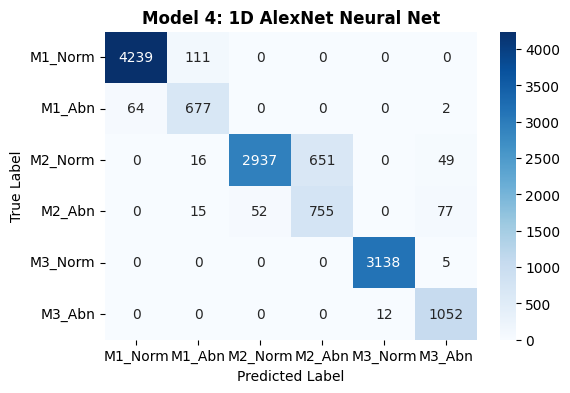

In [8]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

print("🚀 TRAINING MODEL 4: 1D ALEXNET-STYLE NEURAL NET (TENSORFLOW)\n" + "="*50)

# 1. Custom Focal Loss for TensorFlow
class FocalLossTF(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        # Calculate standard categorical crossentropy
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)
        # Calculate probability of the correct class
        pt = tf.exp(-ce_loss)
        # Apply focal weight
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss
        return tf.reduce_mean(focal_loss)

# 2. "AlexNet" style equivalent for 1D tabular
def build_deep_alexnet_1d(in_dim, out_dim):
    inputs = layers.Input(shape=(in_dim,))
    
    x = layers.Dense(1024)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(out_dim, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name="DeepAlexNet1D_TF")

# 3. Preparation & Scaling
scaler_alex = StandardScaler()
X_cv_scaled = scaler_alex.fit_transform(X_cv)
X_test_scaled = scaler_alex.transform(X_test)

# Compute class weights for handling imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_cv), y=y_cv)
cw_dict = dict(enumerate(cw))

# 4. Compilation with Cosine Annealing
epochs = 60
batch_size = 32
steps_per_epoch = len(X_cv_scaled) // batch_size

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=epochs * steps_per_epoch
)

tf_alexnet = build_deep_alexnet_1d(X_cv_scaled.shape[1], 6)
tf_alexnet.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-3),
    loss=FocalLossTF(gamma=2.0),
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# 5. Training
print("Training 1D AlexNet (TensorFlow)...")
tf_alexnet.fit(
    X_cv_scaled, y_cv,
    epochs=epochs, 
    batch_size=batch_size,
    class_weight=cw_dict,
    verbose=1,
    callbacks=[early_stop]
)

# 6. Inference & Timing
t0 = time.perf_counter()
probs_tf_alex = tf_alexnet.predict(X_test_scaled, batch_size=batch_size, verbose=0)
preds_tf_alex = np.argmax(probs_tf_alex, axis=1)
t1 = time.perf_counter()

tf_alex_time_ms = ((t1 - t0) / len(X_test_scaled)) * 1000

print(f"\n⏱️ Model 4 (TF AlexNet) Avg Inference Time: {tf_alex_time_ms:.4f} ms / sample")
print("\n--- MODEL 4 METRICS (1D AlexNet NN) ---")
print(classification_report(y_test, preds_tf_alex, target_names=target_names))
plot_cm(y_test, preds_tf_alex, "Model 4: 1D AlexNet Neural Net", target_names)

🚀 TRAINING MODEL 6: FEATURE TRANSFORMER (SELF-ATTENTION MLP)


Model: "FeatureTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 256, 1)    │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 256, 64)   │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 256, 64)   │          0 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     16,640 │ add_9[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 256, 64)   │          0 │ add_9[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 64)   │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 256, 256)  │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 256, 256)  │          0 │ dense_41[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 256, 64)   │     16,448 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 256, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 256, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 256, 256)  │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 256, 256)  │          0 │ dense_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 256, 64)   │     16,448 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 256, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_44[0][0]  

 Total params: 167,046 (652.52 KB)

 Trainable params: 167,046 (652.52 KB)

 Non-trainable params: 0 (0.00 B)


Training Feature Transformer...
Epoch 1/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.5971 - loss: 0.5422 - val_accuracy: 0.7358 - val_loss: 0.3569
Epoch 2/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.7734 - loss: 0.2797 - val_accuracy: 0.7386 - val_loss: 0.3177
Epoch 3/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8150 - loss: 0.2127 - val_accuracy: 0.8349 - val_loss: 0.1951
Epoch 4/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8826 - loss: 0.1312 - val_accuracy: 0.8724 - val_loss: 0.1317
Epoch 5/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9003 - loss: 0.1067 - val_accuracy: 0.8754 - val_loss: 0.1205
Epoch 6/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9158 - loss: 0.0859 - val_accuracy: 0.8934 - val_loss: 0.1013
Epoch 7/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9270 - loss: 0.0766 - val_accuracy: 0.9092 - val_loss: 0.0717
Epoch 8/60
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2

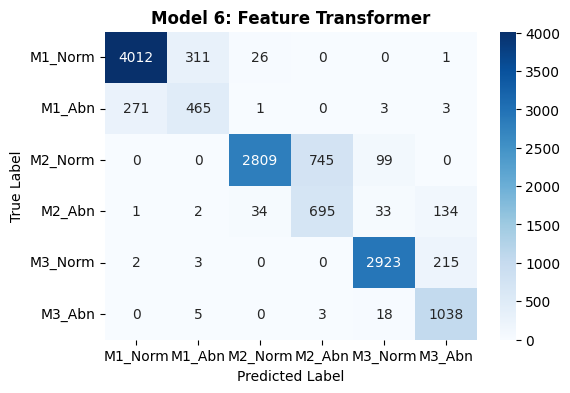

In [9]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
# Add to Cell 1, after the TF imports

class FocalLossTF(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)
        pt = tf.exp(-ce_loss)
        return tf.reduce_mean(((1.0 - pt) ** self.gamma) * ce_loss)
        
print("🚀 TRAINING MODEL 6: FEATURE TRANSFORMER (SELF-ATTENTION MLP)\n" + "="*50)

def build_feature_transformer(in_dim, out_dim, num_heads=4, ff_dim=256, num_blocks=3, embed_dim=64):
    """
    Transformer encoder for tabular/flat feature data.
    Each feature is projected to embed_dim and treated as a token.
    Multi-head self-attention captures global feature interactions.
    """
    inputs = layers.Input(shape=(in_dim,))

    # --- Embed each feature as a token: (batch, in_dim) → (batch, in_dim, embed_dim) ---
    x = layers.Reshape((in_dim, 1))(inputs)
    x = layers.Dense(embed_dim)(x)                          # linear projection per feature

    # --- Learnable positional encoding ---
    positions = tf.range(start=0, limit=in_dim, delta=1)
    pos_embed = layers.Embedding(input_dim=in_dim, output_dim=embed_dim)(positions)
    x = x + pos_embed                                       # broadcast add

    # --- Transformer Encoder Blocks ---
    for _ in range(num_blocks):
        # Multi-Head Self-Attention
        attn_out = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1
        )(x, x)
        x = layers.Add()([x, attn_out])
        x = layers.LayerNormalization(epsilon=1e-6)(x)

        # Feed-Forward sublayer
        ff = layers.Dense(ff_dim, activation='relu')(x)
        ff = layers.Dropout(0.2)(ff)
        ff = layers.Dense(embed_dim)(ff)
        x = layers.Add()([x, ff])
        x = layers.LayerNormalization(epsilon=1e-6)(x)

    # --- Classification head ---
    x = layers.GlobalAveragePooling1D()(x)                 # aggregate across token dim
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(out_dim, activation='softmax')(x)

    return models.Model(inputs, outputs, name="FeatureTransformer")

# --- Prepare data ---
scaler_transformer = StandardScaler()
X_cv_tr   = scaler_transformer.fit_transform(X_cv)
X_test_tr = scaler_transformer.transform(X_test)

cw = compute_class_weight('balanced', classes=np.unique(y_cv), y=y_cv)
cw_dict = dict(enumerate(cw))

epochs = 60
batch_size = 32
steps_per_epoch = len(X_cv_tr) // batch_size

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4, decay_steps=epochs * steps_per_epoch, alpha=1e-6
)

transformer_model = build_feature_transformer(X_cv_tr.shape[1], 6)
transformer_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss=FocalLossTF(gamma=2.0),
    metrics=['accuracy']
)
transformer_model.summary()

cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print("\nTraining Feature Transformer...")
transformer_model.fit(
    X_cv_tr, y_cv,
    epochs=epochs, batch_size=batch_size,
    validation_split=0.1,
    class_weight=cw_dict,
    callbacks=cb_list,
    verbose=1
)

# --- Inference & Evaluation ---
t0 = time.perf_counter()
probs_transformer = transformer_model.predict(X_test_tr, batch_size=batch_size, verbose=0)
preds_transformer = np.argmax(probs_transformer, axis=1)
t1 = time.perf_counter()

transformer_time_ms = ((t1 - t0) / len(X_test_tr)) * 1000

print(f"\n⏱️ Model 6 (Feature Transformer) Avg Inference Time: {transformer_time_ms:.4f} ms / sample")
print("\n--- MODEL 6 METRICS (Feature Transformer) ---")
print(classification_report(y_test, preds_transformer, target_names=target_names))
plot_cm(y_test, preds_transformer, "Model 6: Feature Transformer", target_names)

🤝 CELL 6: ENSEMBLE & CONFLICT ANALYSIS

📊 Individual Model Accuracies:
----------------------------------------
  AlexNet                   0.9239
  SVM + Deep Res MLP        0.8470
  SVM + Shallow NN          0.8961


--- 🗳️  Ensemble: HARD VOTING Metrics ---
              precision    recall  f1-score   support

     M1_Norm       0.99      0.98      0.98      4350
      M1_Abn       0.84      0.92      0.88       743
     M2_Norm       0.97      0.77      0.86      3653
      M2_Abn       0.48      0.87      0.62       899
     M3_Norm       0.99      1.00      1.00      3143
      M3_Abn       0.98      0.98      0.98      1064

    accuracy                           0.92     13852
   macro avg       0.87      0.92      0.89     13852
weighted avg       0.94      0.92      0.92     13852



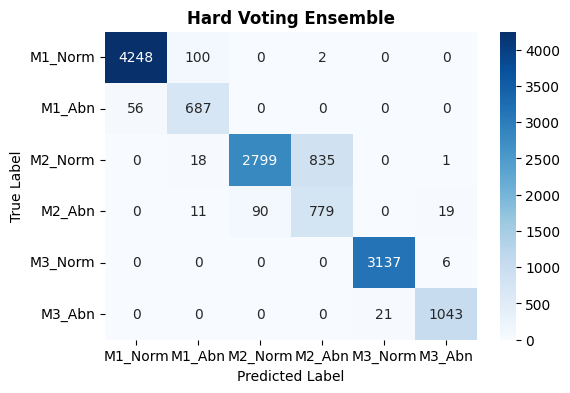


--- 🧮  Ensemble: SOFT VOTING Metrics ---
              precision    recall  f1-score   support

     M1_Norm       0.99      0.98      0.98      4350
      M1_Abn       0.87      0.93      0.90       743
     M2_Norm       0.99      0.76      0.86      3653
      M2_Abn       0.49      0.94      0.64       899
     M3_Norm       0.99      1.00      1.00      3143
      M3_Abn       0.98      0.98      0.98      1064

    accuracy                           0.92     13852
   macro avg       0.88      0.93      0.89     13852
weighted avg       0.95      0.92      0.93     13852



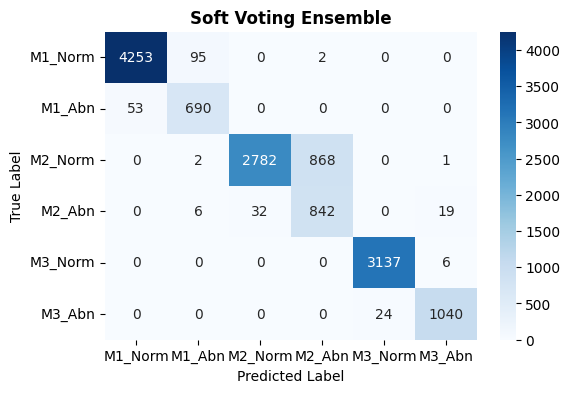


🔬 AGREEMENT BREAKDOWN (Hard Vote)
  All 3 models agreed : 11406 samples  →  Hard-vote acc: 0.9582
  ≥2/3 models agreed : 13723 samples  →  Hard-vote acc: 0.9214
  ≥1/3 models agreed : 13852 samples  →  Hard-vote acc: 0.9163

🔴 WRONG-DECISION CONFLICT MATRIX (Hard Vote)


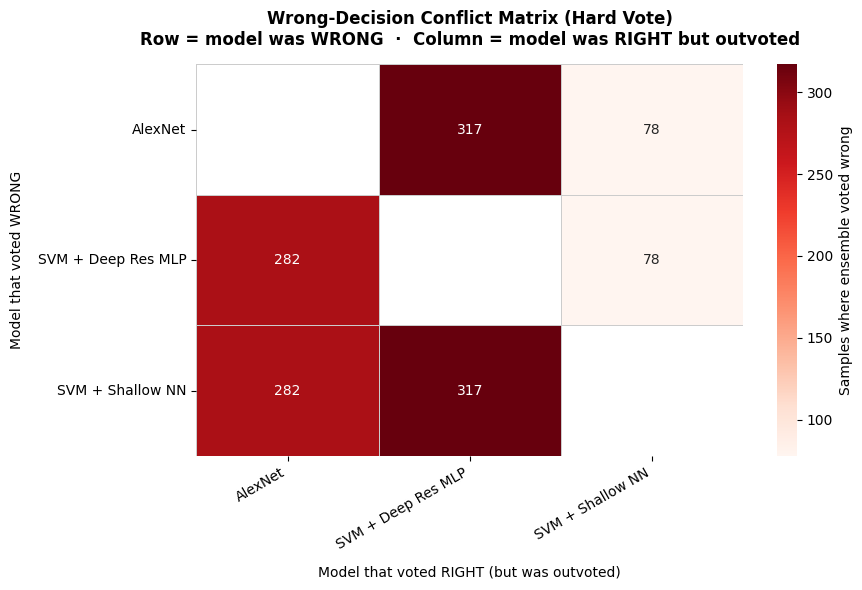


⏱️  INFERENCE TIME SUMMARY (ms / sample)
---------------------------------------------
  AlexNet                   0.1196 ms
  SVM + Deep Res MLP        0.3335 ms
  SVM + Shallow NN          0.2273 ms
  SVM + XGBoost             0.0160 ms

  Ensemble (bounded by slowest) ~0.3335 ms


In [10]:
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score

print("🤝 CELL 6: ENSEMBLE & CONFLICT ANALYSIS")
print("=" * 50)

# ─────────────────────────────────────────────────────
# 0. REGISTER ALL TRAINED MODELS
#    Each entry: (name, final_preds, final_probs_6class)
#    probs must be shape (N, 6) — already weighted by router where applicable
# ─────────────────────────────────────────────────────

# Build AlexNet 6-class prob matrix (end-to-end, no router weighting needed)
alexnet_final_probs = probs_tf_alex                          # shape (N, 6) directly
alexnet_final_preds = preds_tf_alex

# Build Transformer 6-class prob matrix
transformer_final_probs_ens = probs_transformer              # shape (N, 6) directly
transformer_final_preds_ens = preds_transformer

# NOTE: xgb_final_probs, lgbm_final_probs, deep_nn_final_probs,
#       xgb_final_preds, lgbm_final_preds, deep_nn_final_preds,
#       nn_final_preds are all already defined from their respective cells.

# Build shallow NN 6-class prob matrix (it only saved preds, not probs → reconstruct one-hot style)
# We use a hard one-hot so it contributes equally in soft vote
nn_final_probs = np.zeros((len(y_test), 6))
nn_final_probs[np.arange(len(y_test)), nn_final_preds] = 1.0

model_registry = [
    ("AlexNet",            alexnet_final_preds,      alexnet_final_probs),
    ("SVM + Deep Res MLP", deep_nn_final_preds,      deep_nn_final_probs),
    ("SVM + Shallow NN",   nn_final_preds,            nn_final_probs),
]

model_names = [m[0] for m in model_registry]
all_preds   = [m[1] for m in model_registry]
all_probs   = [m[2] for m in model_registry]
n_models    = len(model_registry)

# ─────────────────────────────────────────────────────
# 1. INDIVIDUAL MODEL ACCURACIES
# ─────────────────────────────────────────────────────
print("\n📊 Individual Model Accuracies:")
print("-" * 40)
for name, preds, _ in model_registry:
    acc = accuracy_score(y_test, preds)
    print(f"  {name:<25} {acc:.4f}")

# ─────────────────────────────────────────────────────
# 2. HARD VOTING (Majority Rule across all 5 models)
# ─────────────────────────────────────────────────────
stacked_preds = np.vstack(all_preds)                         # (n_models, N)
hard_vote_preds, _ = stats.mode(stacked_preds, axis=0)
hard_vote_preds = hard_vote_preds.flatten().astype(int)

print("\n\n--- 🗳️  Ensemble: HARD VOTING Metrics ---")
print(classification_report(y_test, hard_vote_preds, target_names=target_names))
plot_cm(y_test, hard_vote_preds, "Hard Voting Ensemble", target_names)

# ─────────────────────────────────────────────────────
# 3. SOFT VOTING (Average probabilities across all 5 models)
# ─────────────────────────────────────────────────────
soft_vote_probs = np.mean(np.stack(all_probs, axis=0), axis=0)   # (N, 6)
soft_vote_preds = np.argmax(soft_vote_probs, axis=1)

print("\n--- 🧮  Ensemble: SOFT VOTING Metrics ---")
print(classification_report(y_test, soft_vote_preds, target_names=target_names))
plot_cm(y_test, soft_vote_preds, "Soft Voting Ensemble", target_names)

# ─────────────────────────────────────────────────────
# 4. AGREEMENT BREAKDOWN (Hard Vote)
# ─────────────────────────────────────────────────────
print("\n🔬 AGREEMENT BREAKDOWN (Hard Vote)\n" + "=" * 50)

# Per-model correctness mask
correct_masks = [(preds == y_test) for preds in all_preds]

# Count how many models agreed on the hard vote winner per sample
agreement_counts = np.sum(
    np.vstack(all_preds) == hard_vote_preds[np.newaxis, :], axis=0
)  # shape (N,)

for threshold in [n_models, n_models - 1, n_models - 2]:
    mask = agreement_counts >= threshold
    n = np.sum(mask)
    if n == 0:
        continue
    acc = accuracy_score(y_test[mask], hard_vote_preds[mask])
    label = f"All {n_models}" if threshold == n_models else f"≥{threshold}/{n_models}"
    print(f"  {label} models agreed : {n:5d} samples  →  Hard-vote acc: {acc:.4f}")

# ─────────────────────────────────────────────────────
# 5. WRONG-DECISION CONFLICT MATRIX (Hard Vote)
#    Cell [i, j] = samples where model i was WRONG
#                  AND the hard vote final answer was WRONG
#                  AND model j was RIGHT
#    → "model j could have saved the vote but was outvoted by others incl. model i"
# ─────────────────────────────────────────────────────
print("\n🔴 WRONG-DECISION CONFLICT MATRIX (Hard Vote)\n" + "=" * 50)

hard_vote_wrong = (hard_vote_preds != y_test)          # samples where ensemble was wrong

conflict_matrix = np.zeros((n_models, n_models), dtype=int)

for i, (_, preds_i, _) in enumerate(model_registry):
    for j, (_, preds_j, _) in enumerate(model_registry):
        if i == j:
            continue
        # Hard vote was wrong, model i was also wrong, but model j was right
        condition = hard_vote_wrong & (preds_i != y_test) & (preds_j == y_test)
        conflict_matrix[i, j] = np.sum(condition)

conflict_df = pd.DataFrame(conflict_matrix, index=model_names, columns=model_names)

fig, ax = plt.subplots(figsize=(9, 6))
mask_diag = np.eye(n_models, dtype=bool)

sns.heatmap(
    conflict_df,
    annot=True,
    fmt='d',
    cmap='Reds',
    mask=mask_diag,
    linewidths=0.5,
    linecolor='#cccccc',
    ax=ax,
    cbar_kws={'label': 'Samples where ensemble voted wrong'}
)

ax.set_title(
    "Wrong-Decision Conflict Matrix (Hard Vote)\n"
    "Row = model was WRONG  ·  Column = model was RIGHT but outvoted",
    fontweight='bold', pad=14
)
ax.set_ylabel("Model that voted WRONG", labelpad=10)
ax.set_xlabel("Model that voted RIGHT (but was outvoted)", labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────
# 6. INFERENCE TIME SUMMARY
# ─────────────────────────────────────────────────────
print("\n⏱️  INFERENCE TIME SUMMARY (ms / sample)")
print("-" * 45)
time_map = {
    "AlexNet":            tf_alex_time_ms,
    "SVM + Deep Res MLP": deep_nn_time_ms,
    "SVM + Shallow NN":   nn_time_ms,
    "SVM + XGBoost":      xgb_pipeline_time_ms,
}
for name, t in time_map.items():
    print(f"  {name:<25} {t:.4f} ms")
print(f"\n  {'Ensemble (bounded by slowest)':<25} ~{max(time_map.values()):.4f} ms")

In [11]:
# import scipy.stats as stats

# print("🤝 CELL 6: ENSEMBLE & CONFLICT ANALYSIS\n" + "="*50)

# # 1. HARD VOTING (Majority Rule)
# stacked_preds = np.vstack([xgb_final_preds, lgbm_final_preds, tf_final_preds])
# hard_vote_preds, _ = stats.mode(stacked_preds, axis=0)
# hard_vote_preds = hard_vote_preds.flatten()

# # 2. SOFT VOTING (Averaging Probabilities)
# soft_vote_probs = (xgb_final_probs + lgbm_final_probs + tf_final_probs) / 3.0
# soft_vote_preds = np.argmax(soft_vote_probs, axis=1)

# print("\n--- Ensemble: Hard Voting Metrics ---")
# print(classification_report(y_test, hard_vote_preds, target_names=target_names))

# print("\n--- Ensemble: Soft Voting Metrics ---")
# print(classification_report(y_test, soft_vote_preds, target_names=target_names))
# plot_cm(y_test, soft_vote_preds, "Soft Voting Ensemble Classification", target_names)

# # 3. CONFLICT MATRIX (Agreement vs Correctness Analysis)
# print("\n🔬 CONFLICT MATRIX ANALYSIS\n" + "="*50)
# # We will identify how many models agreed and whether they were correct.

# agree_all = (xgb_final_preds == lgbm_final_preds) & (lgbm_final_preds == tf_final_preds)
# agree_two = ((xgb_final_preds == lgbm_final_preds) | 
#              (xgb_final_preds == tf_final_preds) | 
#              (lgbm_final_preds == tf_final_preds)) & ~agree_all
# agree_none = ~(agree_all | agree_two)

# correct_soft = (soft_vote_preds == y_test)

# print(f"Total Test Samples: {len(y_test)}")
# print(f"✅ All 3 Models Agreed: {np.sum(agree_all)} samples (Acc: {accuracy_score(y_test[agree_all], soft_vote_preds[agree_all]):.4f})")
# print(f"⚠️ Exactly 2 Models Agreed: {np.sum(agree_two)} samples (Acc: {accuracy_score(y_test[agree_two], soft_vote_preds[agree_two]):.4f})")
# print(f"❌ No Models Agreed: {np.sum(agree_none)} samples")

# # Pairwise Conflict Matrix: Rows = Model A Wrong, Columns = Model B Right
# models = {'XGB': xgb_final_preds, 'LGBM': lgbm_final_preds, 'ResNet': tf_final_preds}
# conflict_matrix = pd.DataFrame(0, index=models.keys(), columns=models.keys())

# for m1_name, m1_preds in models.items():
#     for m2_name, m2_preds in models.items():
#         if m1_name == m2_name:
#             continue
#         # Count cases where Model 1 was WRONG, but Model 2 was RIGHT
#         condition = (m1_preds != y_test) & (m2_preds == y_test)
#         conflict_matrix.loc[m1_name, m2_name] = np.sum(condition)

# plt.figure(figsize=(7, 5))
# sns.heatmap(conflict_matrix, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'Number of Samples'})
# plt.title("Conflict Matrix\n(Row = Model was WRONG, Column = Model was RIGHT)", fontweight='bold')
# plt.ylabel('Model that Failed')
# plt.xlabel('Model that Succeeded')
# plt.show()

# # Inference Time Summary
# print("\n⏱️ INFERENCE TIME SUMMARY (ms/sample)")
# print("-" * 40)
# print(f"SVM + XGBoost Pipeline : {xgb_pipeline_time_ms:.4f} ms")
# print(f"SVM + LightGBM Pipeline: {lgbm_pipeline_time_ms:.4f} ms")
# print(f"1D ResNet (TensorFlow) : {tf_time_ms:.4f} ms")
# print(f"Ensemble (Parallel)    : ~{max(xgb_pipeline_time_ms, lgbm_pipeline_time_ms, tf_time_ms):.4f} ms (Bounded by slowest)")

In [12]:
# sdvsdc